# Simulation
# Group Project 1
## BoxCar Ride-Sharing Simulation

**Authors:**
1. Erin Fortin 
2. Alice Locker
3. Colin McDonagh

**Date:** Friday, 6 March 2026

---

This notebook implements a discrete-event simulation of the BoxCar ride-sharing system operating in Squareshire county.

The simulation models the interactions between drivers and riders, including:
- driver arrivals and departures
- rider arrivals and patience behavior (abandonment)
- driver–rider matching
- pickup and trip completion

### Model Overview

The main events modeled in the system are:

1. Driver Arrival
2. Rider Arrival
3. Pickup Start
4. Pickup
5. Dropoff
6. Rider Abandonment
7. Driver Offline
8. Termination

The simulation continues until the termination time is reached.

### Simulation Assumptions

The distributions of the driver and rider arrivals, travel times, and locations are assumed from the project brief from BoxCar. 

## 0. Import Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

## 1. Parameters and Functions
The constant parameters of the system include:
- Side length of Squareshire
- Travel speed 
- Base fare for a trip
- Additional cost per mile 
- Petrol cost per mile

In [2]:
county_size = 20 # miles
taxi_speed = 20 # miles per hour
base_fare = 3.00 # pounds
per_mile_fare = 2.00 # pounds per mile
petrol_cost = 0.2 # pounds per mile

## 2. Helper Functions

The following functions support the simulation model.

These functions include:

- generating random driver and rider locations
- computing Euclidean distance between points
- converting travel distance into travel time

In [3]:
def distance(loc1, loc2):
    '''Calculate Euclidean distance between two locations (list: [x,y])'''
    return np.sqrt((loc1[0] - loc2[0])**2 + (loc1[1] - loc2[1])**2)

def generate_location(entity, dist_mode="baseline"):
    
    if dist_mode == "baseline":
        return (
            random.uniform(0, county_size),
            random.uniform(0, county_size)
        )

    elif dist_mode == "fitted":

        if entity == "rider_pickup":
            mean = [8.36, 12.32]
            cov = [[18.12, 2.47],
                   [2.47, 17.56]]

        elif entity == "rider_dropoff":
            mean = [11.23, 13.26]
            cov = [[20.60, 2.21],
                   [2.21, 17.38]]

        elif entity == "driver":
            mean = [9.97, 11.51]
            cov = [[18.29, -0.54],
                   [-0.54, 18.06]]

        # rejection sampling
        while True:
            x, y = np.random.multivariate_normal(mean, cov)

            if 0 <= x <= county_size and 0 <= y <= county_size:
                return (x, y)

def travel_time(d_OD, dist_mode="baseline"):
    '''Calculate the expected travel time mu_t, then generate the actual travel time 
    from the assumed distribition'''
    mu = d_OD / taxi_speed
    if dist_mode == 'baseline':
        return random.uniform(0.8*mu, 1.2*mu) 
    elif dist_mode == 'fitted':
        return random.uniform(0.7*mu, 1.3*mu) 

## 3. Simulation Model

The core of the model is implemented in the function `run_simulation()`.

This function simulates the system of the ride-sharing platform for a specified number of hours. The simulation maintains an event calendar that determines the order in which events occur.

The function tracks system performance metrics including:

- number of drivers and riders
- total rides completed
- driver earnings
- rider waiting times
- abandoned rides

In [4]:
def run_simulation(T, lambda1, lambda2, dist_mode = 'baseline'):
    ''' Runs the rideshare Simulation with either BoxCar's initial parameter assumptions or
    our empirically derived parameter assumptions. 
            Inputs:
            - T: Termination Time (in hours)
            - lambda_1: penalty parameter for profit rates
            - lambda_2: penalty parameter for break times
            - dist_mode: either 'baseline' (uses BoxCar's believed parameter values) 
            or 'fitted' (uses empirically derived parameter values.)
            Output:
            - results: dictionary of performance metrics indexed by metric type '''

    ##################################
    # Initialize Performance Metrics #  
    ##################################    
    N_D = 0
    N_R = 0
    T_D = 0
    T_R = 0
    P = 0
    R = 0                   # total completed rides
    matched_rides = 0       # started but dropoff is after TerminationTime - do not count driver earnings
    picked_up_rides = 0     # matched and actually gets picked up before TerminationTime
    abandoned_rides = 0     # abandoned due to patience time being reached
    T_P = []
    T_All = []
    T_W = []
    driver_ride_counts = {}
    driver_idle_time = {}
    driver_last_busy_time = {}

    ###############################
    # Initialize Simulation State #  
    ###############################        
    TNOW = 0
    TerminationTime = T #hrs
    EventCalendar = []
    def schedule_event(time, event_type, data=None):
        '''Event scheduler that keeps track of times, event type, and user data (optional)'''
        EventCalendar.append((time,event_type,data))
   
    drivers =[]
    idle_drivers=[]
    riders = []
    waiting_riders=[]

    driver_id_counter = 0
    rider_id_counter = 0

    # Schedule first arrivals and termination events
    # driver arrival
    if dist_mode == "baseline":
        driver_arrival = random.expovariate(3)
    else:
        driver_arrival = random.expovariate(4.75)
    schedule_event(driver_arrival, 1)          # 1 = Driver Arrival

    # Rider arrival 
    if dist_mode == "baseline":
        rider_arrival = random.expovariate(30)
    else:
        rider_arrival = random.expovariate(35)

    schedule_event(rider_arrival, 2)           # 2 = Rider Arrival


    schedule_event(TerminationTime, 8)         # 8 = Termination

    # Matching decisions are made using this scoring rule:
    def driver_score(driver, rider, TNOW, lambda1, lambda2):
        '''calculate the score of the driver according to 
            score = distance + l1*profit_per_driver/online_time - l2*current_break_time'''
        
        d = distance(driver['location'], rider['origin'])
        
        # small constant 1e-6 prevents division by zero if driver just went online.
        time_active = TNOW - driver['online_time'] + 1e-6
        
        profit_rate = driver['earnings'] / time_active
        
        break_time = TNOW - driver_last_busy_time[driver['id']]

        return d + lambda1 * profit_rate - lambda2 * break_time
    
    #########################
    # Event Processing Loop #
    #########################
    while TNOW < TerminationTime:
        TNEXT, TypeNext, Data = min(EventCalendar, key=lambda x: x[0])
        EventCalendar.remove((TNEXT, TypeNext, Data))
        TNOW = TNEXT

        ### 1. DriverArrival ###
        if TypeNext == 1:
            driver_id_counter += 1

            # Generate offline time 
            if dist_mode == "baseline":
                online_time = random.uniform(5,8)
            else:
                online_time = random.uniform(6,8)

            # Driver attributes
            driver = {
                "id": driver_id_counter,
                "location": generate_location("driver", dist_mode),
                'offline_time': TNOW + online_time,
                'idle': True,
                'active': True,
                'earnings': 0,
                'online_time': TNOW
            }
            drivers.append(driver)

            # Update performance metrics immediately
            N_D += 1
            driver['online_time'] = TNOW
            driver_ride_counts[driver['id']] = 0
            driver_idle_time[driver['id']] = 0
            driver_last_busy_time[driver['id']] = TNOW

            # Schedule offline time
            schedule_event(driver['offline_time'], event_type=7, data = driver)

            # Match driver to waiting rider
            if waiting_riders:
                # match closest waiting rider
                rider = min(
                    waiting_riders,
                    key=lambda r: driver_score(driver, r, TNOW, lambda1, lambda2)
                )
                waiting_riders.remove(rider)
                
                # update statuses
                rider['status'] = 'matched'
                driver['idle'] = False
                
                # schedule pickup start
                schedule_event(TNOW, event_type=3, data = (driver, rider)) 

                # update performance metrics
                matched_rides += 1
            else:
                idle_drivers.append(driver)
            
            # Schedule next driver arrival
            if dist_mode == "baseline":
                schedule_event(TNOW + random.expovariate(3), 1)
            else:
                schedule_event(TNOW + random.expovariate(4.75), 1)

        ### 2. RiderArrival ###
        elif TypeNext == 2: 
            rider_id_counter += 1

            # Generate rider location and patience time (initialize other attributes)
            rider = {
                "id": rider_id_counter,
                "origin": generate_location("rider_pickup", dist_mode),
                "destination": generate_location("rider_dropoff", dist_mode),
                'patience_time': random.expovariate(5),
                'status': 'waiting'
            }
            riders.append(rider)
            
            # Match driver to idle active driver
            idle_active_drivers = [driver for driver in idle_drivers if driver['active']]

            if idle_active_drivers:
                # Use weighted matching metric
                driver = min(idle_active_drivers,
                    key=lambda d: driver_score(d, rider, TNOW, lambda1, lambda2)
                )
                # update statuses
                idle_drivers.remove(driver)
                rider['status'] = 'matched'
                driver['idle'] = False

                # schedule PickupStart
                schedule_event(TNOW, event_type=3, data = (driver,rider))

                # update performance metrics
                matched_rides += 1
            else:
                waiting_riders.append(rider)

                #schedule patience deadline for waiting rider
                schedule_event(TNOW+rider['patience_time'], event_type=6, data = rider)
            
            # schedule next rider arrival
            if dist_mode == "baseline":
                schedule_event(TNOW + random.expovariate(30), 2)
            else:
                schedule_event(TNOW + random.expovariate(35), 2)

            # Update performance metrics
            N_R += 1
            rider['arrival_time'] = TNOW
            #T_P.append(rider['patience_time'])

        ### 3. PickupStart ###
        elif TypeNext == 3:
            driver,rider = Data

            # in very rare event that driver becomes offline at exact time it gets matched, 
            # add rider back to waiting list
            if not driver['active']:
                rider['status'] = 'waiting'
                waiting_riders.append(rider)
                continue
            
            # Calculate actual travel time 
            d_P = distance(driver['location'],rider['origin'])
            t_P = travel_time(d_P, dist_mode)

            # Schedule Pickup event
            schedule_event(TNOW + t_P, event_type=4, data = (driver,rider,d_P))

            # Update performance metrics
            waiting_time = TNOW - rider['arrival_time']  # time waited between rider arrival and matching
            T_W.append(waiting_time)
            T_All.append(waiting_time)
            T_P.append(rider['patience_time'])
            driver_ride_counts[driver['id']] += 1
            driver_idle_time[driver['id']] += TNOW - driver_last_busy_time[driver['id']]
            driver_last_busy_time[driver['id']] = TNOW
            
        
        ### 4. Pickup ###
        elif TypeNext == 4:
            driver, rider, d_P = Data
            
            # Calculate actual travel time
            d_OD = distance(rider['origin'], rider['destination'])
            t_OD = travel_time(d_OD, dist_mode)

            # Schedule Dropoff
            schedule_event(TNOW + t_OD, event_type=5, data = (driver,rider,d_P,d_OD,t_OD))

            # update performance metrics
            picked_up_rides += 1

        ### 5. Dropoff ###
        elif TypeNext == 5:
            driver, rider, d_P, d_OD,t_OD = Data

            # update rider status
            rider["status"] = "dropped-off"

            # calculate driver earnings
            rider_fare = base_fare + per_mile_fare * d_OD
            driver_cost = petrol_cost*(d_P+d_OD)
            driver_profit = rider_fare - driver_cost
            driver['earnings'] += driver_profit      # changed this to make it cumulative profit
            
            # Update driver information
            driver['location'] = rider['destination']
            driver['idle'] = True

            # Check if driver is meant to be offline now
            if TNOW >= driver['offline_time']:
                driver['active'] = False
            else:
                if waiting_riders:
                    # pick the rider for which the driver has the lowest penalty cost
                    next_rider = min(
                        waiting_riders,
                        key=lambda r: driver_score(driver, r, TNOW, lambda1, lambda2)
                    )
                    waiting_riders.remove(next_rider)
                    next_rider['status'] = 'matched'
                    driver['idle'] = False
                    # schedule next pickup if driver gets matched to a new rider
                    schedule_event(TNOW, event_type=3, data = (driver, next_rider))

                    # update performance metrics
                    matched_rides += 1
                else:
                    idle_drivers.append(driver)

            # Update performance metrics
            R += 1
            T_R += t_OD  
            P += driver_profit
            driver_last_busy_time[driver['id']] = TNOW
        
        ### 6. RiderAbandonment ###
        elif TypeNext == 6:
            rider = Data

            # remove abandonded riders and update status
            if rider['status'] == 'waiting':
                waiting_riders.remove(rider)
                rider["status"] = "abandoned"
                abandoned_rides += 1

                # Update performance metrics
                T_All.append(rider['patience_time'])
                T_P.append(rider['patience_time'])
        
        ### 7. DriverOffline ###
        elif TypeNext == 7:
            driver = Data
            
            # remove offline drivers and update status
            if driver["active"] and driver["idle"]:
                driver["active"] = False
                if driver in idle_drivers:
                    idle_drivers.remove(driver)

            # Update performance metrics
            T_D += TNOW - driver['online_time']
            driver_idle_time[driver['id']] += TNOW - driver_last_busy_time[driver['id']]

        ### 8. Termination ###
        else:
            # Update performance metrics
            for driver in drivers:
                if driver['active']:
                    T_D += TNOW - driver['online_time']
                    
                    if driver['idle']:
                        driver_idle_time[driver['id']] += TNOW - driver_last_busy_time[driver['id']]
    
    #########################
    # Collect Final Results #
    #########################
    results = {
        "system_metrics": {
            "N_D": N_D,
            "N_R": N_R,
            "R": R,
            "matched_rides": matched_rides,
            "picked_up_rides": picked_up_rides,
            "abandoned_rides": abandoned_rides,
            'TerminationTime': T
        },
    
        "financial_metrics": {
            "P": P
        },

        "time_metrics": {
            "T_D": T_D,
            "T_R": T_R,
            "T_W": T_W,
            "T_P": T_P,
            "T_All": T_All
        },

        "driver_metrics": {
            "driver_ride_counts": driver_ride_counts,
            "driver_idle_time": driver_idle_time,
            "driver_last_busy_time": driver_last_busy_time
        },

        "entities": {
            "drivers": drivers,
            "riders": riders
        }
    }

    return results


## 4. Running the Simulation

We first run the simulation using the baseline parameter values to observe the system's behavior under the original BoxCar distributional assumptions and dispatch policy. 

### Performance Metrics Functions

In [5]:
def compute_metrics(sim_results):
    '''
    Input: results dictionary returned by run_simulation.
    Outputs the following performance metrics for this instance of the simulation:
    - 'abandonment_rate': 
    - 'avg_wait_matched': 
    - 'avg_wait_all': 
    - 'all_wait_ratios':
    - 'match_wait_ratios':
    - 'avg_PT_wait_all':
    - 'avg_PT_wait_matched':
    - 'avg_earnings_per_hour': 
    - 'avg_driver_profit':
    - 'avg_idle_time_per_ride':
    - 'driver_idle_per_ride':
    - 'idle_proportion':
    '''

    sys = sim_results["system_metrics"]
    time = sim_results["time_metrics"]
    fin = sim_results["financial_metrics"]
    driver_metrics = sim_results["driver_metrics"]
    driver_idle_time = driver_metrics["driver_idle_time"]
    driver_ride_counts = driver_metrics["driver_ride_counts"]

    N_R = sys["N_R"]
    R = sys["R"]
    abandoned = sys["abandoned_rides"]
    T = sys["TerminationTime"]

    T_D = time["T_D"]
    T_R = time["T_R"]
    T_W = time["T_W"]
    T_P = time["T_P"]
    T_All = time["T_All"]

    P = fin["P"]

    drivers = sim_results["entities"]["drivers"]

    # rider abandonments
    abandonment_rate = abandoned / N_R if N_R else 0

    # rider waiting times
    avg_wait_matched = np.mean(T_W) if T_W else 0
    avg_wait_all = np.mean(T_All) if T_All else 0
    # proportions of patience times waited by matched/all riders
    all_wait_ratios = np.array(T_All) / np.array(T_P) if T_P else np.array([])
    match_wait_ratios = all_wait_ratios[all_wait_ratios < 1]
    avg_PT_wait_all = np.mean(all_wait_ratios)
    avg_PT_wait_matched = np.mean(match_wait_ratios)

    # driver earnings
    avg_earnings_per_hour = P / T_D if T_D else 0
    # driver-level profits
    driver_profits = [d["earnings"] for d in drivers]
    avg_profit = np.mean(driver_profits) if driver_profits else 0

    # fairness among drivers
    driver_rides = list(driver_ride_counts.values())
    
    avg_driver_idle_per_ride = []
    driver_working_ratios = []

    for driver in drivers:
        d_ID = driver["id"]
        rides = driver_ride_counts.get(d_ID, 0)
        idle_time = driver_idle_time.get(d_ID, 0)

        # compute online time
        if driver['active']:
            online_time = T - driver['online_time']
        else:
            online_time = driver['offline_time'] - driver['online_time']

        if rides > 0:
            avg_driver_idle_per_ride.append(idle_time / rides)
        else:
            avg_driver_idle_per_ride.append(0)

        if online_time > 0:
            driver_working_ratios.append((online_time - idle_time) / online_time)
        else:
            driver_working_ratios.append(0)

    avg_rides_per_driver = np.mean(driver_rides)
    avg_working_prop = np.mean(driver_working_ratios)

    # resting times
    avg_idle_time_per_ride = (T_D-T_R) / R if R else 0
    idle_prop = (T_D-T_R) / T_D if T_D else 0

    # return dictionary of computed metrics and arrays for histograms
    return {
        "abandonment_rate": abandonment_rate,
        "avg_wait_matched": avg_wait_matched,
        "avg_wait_all": avg_wait_all,
        'all_wait_ratios': all_wait_ratios,
        'match_wait_ratios': match_wait_ratios,
        'avg_PT_wait_all': avg_PT_wait_all,
        'avg_PT_wait_matched': avg_PT_wait_matched,
        "avg_earnings_per_hour": avg_earnings_per_hour,
        "avg_driver_profit": avg_profit,
        'driver_profits': driver_profits,
        'avg_rides_per_driver': avg_rides_per_driver,
        'avg_working_prop': avg_working_prop,
        'avg_idle_time_per_ride': avg_idle_time_per_ride,
        'driver_idle_per_ride': avg_driver_idle_per_ride,
        "idle_proportion": idle_prop,
    }

In [6]:
from scipy.stats import t

def compute_CIs(metrics_list, alpha=0.05):
    '''
    Uses replicates of simulation to find confidence intervals for performance metrics 
    returned by 'compute_metrics'.

    Input:
    - 'metrics_list': list of dictionaries, where each element is the output of 
        compute_metrics() from one simulation run.

    'alpha': significance level (default 0.05 to return 95% CIs)

    Output:
    - 'results': the following dictionary:
        metric_name : {
            'mean': sample mean,
            'lower': CI lower bound,
            'upper': CI upper bound,
            'std': sample std deviation
        }
    '''

    results = {}

    keys = metrics_list[0].keys()

    for key in keys:

        # collect values for this metric
        values = [m[key] for m in metrics_list]

        # skip vectors/lists/arrays automatically
        if isinstance(values[0], (list, np.ndarray)):
            continue

        values = np.array(values)

        n = len(values)
        mean = np.mean(values)
        s = np.std(values, ddof=1)

        # estimating standard deviation from simulated data so use student's t critical value
        t_crit = t.ppf(1 - alpha/2, df=n-1)
        pm_part = t_crit * s / np.sqrt(n)

        results[key] = {
        "mean": round(mean, 4),
        "CI_lower": round(mean - pm_part, 4),
        "CI_upper": round(mean + pm_part, 4)
        }

    return results

In [7]:
def run_replications(T, l1, l2, dist_mode, n_replications=100):
    '''
    Run simulations and output confidence intervals for performance metrics.
    '''
    metrics_list = []

    for _ in range(n_replications):
        sim_results = run_simulation(T, l1, l2, dist_mode)
        metrics_list.append(compute_metrics(sim_results))

    return compute_CIs(metrics_list)

In [8]:
random.seed(12345)
np.random.seed(12345)
summary_bm = run_replications(100, 0,0, "baseline", 100)
print(summary_bm)

{'abandonment_rate': {'mean': np.float64(0.2838), 'CI_lower': np.float64(0.2768), 'CI_upper': np.float64(0.2908)}, 'avg_wait_matched': {'mean': np.float64(0.0431), 'CI_lower': np.float64(0.0417), 'CI_upper': np.float64(0.0444)}, 'avg_wait_all': {'mean': np.float64(0.0571), 'CI_lower': np.float64(0.0557), 'CI_upper': np.float64(0.0585)}, 'avg_PT_wait_all': {'mean': np.float64(0.4175), 'CI_lower': np.float64(0.4083), 'CI_upper': np.float64(0.4267)}, 'avg_PT_wait_matched': {'mean': np.float64(0.1877), 'CI_lower': np.float64(0.1825), 'CI_upper': np.float64(0.1928)}, 'avg_earnings_per_hour': {'mean': np.float64(22.6126), 'CI_lower': np.float64(22.5439), 'CI_upper': np.float64(22.6814)}, 'avg_driver_profit': {'mean': np.float64(143.074), 'CI_lower': np.float64(142.5589), 'CI_upper': np.float64(143.5891)}, 'avg_rides_per_driver': {'mean': np.float64(7.1673), 'CI_lower': np.float64(7.14), 'CI_upper': np.float64(7.1946)}, 'avg_working_prop': {'mean': np.float64(0.8659), 'CI_lower': np.float64(0

In [9]:
summary_fitted = run_replications(100, 0,0, "fitted", 100)
print(summary_fitted)

{'abandonment_rate': {'mean': np.float64(0.0296), 'CI_lower': np.float64(0.0279), 'CI_upper': np.float64(0.0314)}, 'avg_wait_matched': {'mean': np.float64(0.0031), 'CI_lower': np.float64(0.0029), 'CI_upper': np.float64(0.0033)}, 'avg_wait_all': {'mean': np.float64(0.006), 'CI_lower': np.float64(0.0056), 'CI_upper': np.float64(0.0063)}, 'avg_PT_wait_all': {'mean': np.float64(0.044), 'CI_lower': np.float64(0.0415), 'CI_upper': np.float64(0.0466)}, 'avg_PT_wait_matched': {'mean': np.float64(0.0149), 'CI_lower': np.float64(0.0139), 'CI_upper': np.float64(0.0158)}, 'avg_earnings_per_hour': {'mean': np.float64(16.0745), 'CI_lower': np.float64(15.941), 'CI_upper': np.float64(16.2081)}, 'avg_driver_profit': {'mean': np.float64(108.8185), 'CI_lower': np.float64(107.9263), 'CI_upper': np.float64(109.7108)}, 'avg_rides_per_driver': {'mean': np.float64(7.1492), 'CI_lower': np.float64(7.087), 'CI_upper': np.float64(7.2113)}, 'avg_working_prop': {'mean': np.float64(0.5498), 'CI_lower': np.float64(0.

## 5. Driver-Rider Matching Parameters

To evaluate alternative driver matching strategies, we introduce two parameters to balance driver fairness:

- $\lambda_1$ : penalty applied to drivers with higher profit rates
- $\lambda_2$ : reward applied to drivers who have experienced longer breaks

A grid search is performed across a range of parameter values to evaluate their effect on system performance.

---
A Note on $\lambda_1$:

When $\lambda_1$ is allowed to be near 0, it tends towards that value, even as the upper limit is increased. 

We raised the lower bound of $\lambda_1$ incrementally until the best value was greater than zero, thus resulting in the interval [0.75, 5]. 

In [39]:
lambda1_values = np.linspace(0.75, 10, 15)   
lambda2_values = np.linspace(0, 10, 15) 

TerminationTime = 100
gridsearch_results = []
for l1 in lambda1_values:
    for l2 in lambda2_values:

        sim = run_simulation(T=TerminationTime, lambda1=l1, lambda2=l2, dist_mode='fitted')

        gridsearch_results.append({
            "lambda1": l1,
            "lambda2": l2,
        } | compute_metrics(sim))

### Grid Search Results
The following visualization shows how average earnings per hour varies as a function of $\lambda_1$ and $\lambda_2$. 

lambda1                                                            6.035714
lambda2                                                            1.428571
abandonment_rate                                                   0.066449
avg_wait_matched                                                   0.008616
avg_wait_all                                                       0.013842
all_wait_ratios           [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...
match_wait_ratios         [0.2193377667666675, 0.6175496510402626, 0.108...
avg_PT_wait_all                                                    0.108797
avg_PT_wait_matched                                                0.045363
avg_earnings_per_hour                                             18.115267
avg_driver_profit                                                120.775613
driver_profits            [162.77820429875456, 127.42235730996633, 182.1...
avg_rides_per_driver                                               8.181384
avg_working_

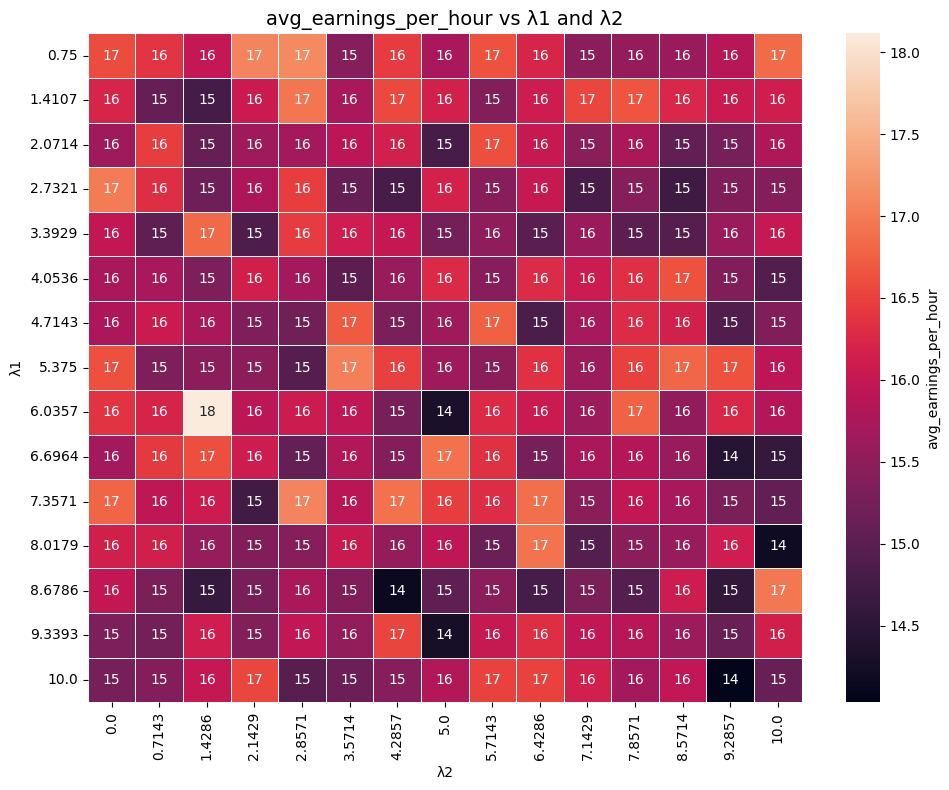

In [40]:
df = pd.DataFrame(gridsearch_results)

best = df.loc[df["avg_earnings_per_hour"].idxmax()]
print(best)

import matplotlib.pyplot as plt
import seaborn as sns

# Round lambda values for cleaner axes
df["lambda1"] = df["lambda1"].round(4)
df["lambda2"] = df["lambda2"].round(4)

# Create pivot table
pivot = df.pivot(index="lambda1", columns="lambda2", values="avg_earnings_per_hour")

plt.figure(figsize=(10,8))

sns.heatmap(
    pivot,
    cmap="rocket",
    annot=True,
    #fmt=".0f",           # remove scientific notation
    linewidths=0.5,
    cbar_kws={"label": "avg_earnings_per_hour"}
)

plt.title("avg_earnings_per_hour vs λ1 and λ2", fontsize=14)
plt.xlabel("λ2")
plt.ylabel("λ1")

plt.tight_layout()
plt.show()

## 6. Implement Driver Fairness Parameters

Next, we run the simulation using the fairness-based matching parameters derived above. 

In [41]:
summary_nm = run_replications(100, best['lambda1'], best['lambda2'], 'fitted', 100)
print(summary_nm)

{'abandonment_rate': {'mean': np.float64(0.0326), 'CI_lower': np.float64(0.0307), 'CI_upper': np.float64(0.0346)}, 'avg_wait_matched': {'mean': np.float64(0.0037), 'CI_lower': np.float64(0.0034), 'CI_upper': np.float64(0.0039)}, 'avg_wait_all': {'mean': np.float64(0.0065), 'CI_lower': np.float64(0.0061), 'CI_upper': np.float64(0.0069)}, 'avg_PT_wait_all': {'mean': np.float64(0.0508), 'CI_lower': np.float64(0.0476), 'CI_upper': np.float64(0.054)}, 'avg_PT_wait_matched': {'mean': np.float64(0.0188), 'CI_lower': np.float64(0.0174), 'CI_upper': np.float64(0.0203)}, 'avg_earnings_per_hour': {'mean': np.float64(15.7035), 'CI_lower': np.float64(15.5695), 'CI_upper': np.float64(15.8376)}, 'avg_driver_profit': {'mean': np.float64(106.4573), 'CI_lower': np.float64(105.5664), 'CI_upper': np.float64(107.3482)}, 'avg_rides_per_driver': {'mean': np.float64(7.1484), 'CI_lower': np.float64(7.0869), 'CI_upper': np.float64(7.2098)}, 'avg_working_prop': {'mean': np.float64(0.6335), 'CI_lower': np.float64

## 7. Analysis of New Matching Implementation 

Finally, we compare the two versions of the model

In [42]:
metrics = summary_bm.keys()

rows = []

for m in metrics:
    rows.append({
        "metric": m,
        "baseline_mean": summary_bm[m]["mean"],
        "baseline_CI_lower": summary_bm[m]["CI_lower"],
        "baseline_CI_upper": summary_bm[m]["CI_upper"],
        "fitted_mean": summary_fitted[m]["mean"],
        "fitted_CI_lower": summary_fitted[m]["CI_lower"],
        "fitted_CI_upper": summary_fitted[m]["CI_upper"],
        "extended_mean": summary_nm[m]["mean"],
        "extended_CI_lower": summary_nm[m]["CI_lower"],
        "extended_CI_upper": summary_nm[m]["CI_upper"]
    })

comparison_df = pd.DataFrame(rows)
comparison_df["Difference(B-F)"] = (
    comparison_df["baseline_mean"] - comparison_df["fitted_mean"]
)
comparison_df["Difference(E-F)"] = (
    comparison_df["extended_mean"] - comparison_df["fitted_mean"]
)


comparison_df.round(4)[['metric','fitted_mean', 'extended_mean',  'Difference(E-F)']]


,metric,fitted_mean,extended_mean,Difference(E-F)
0,abandonment_rate,0.0296,0.0326,0.0030
1,avg_wait_matched,0.0031,0.0037,0.0006
2,avg_wait_all,0.0060,0.0065,0.0005
3,avg_PT_wait_all,0.0440,0.0508,0.0068
4,avg_PT_wait_matched,0.0149,0.0188,0.0039
5,avg_earnings_per_hour,16.0745,15.7035,-0.3710
6,avg_driver_profit,108.8185,106.4573,-2.3612
7,avg_rides_per_driver,7.1492,7.1484,-0.0008
8,avg_working_prop,0.5498,0.6335,0.0837
9,avg_idle_time_per_ride,0.5897,0.5910,0.0013


In [24]:
.0031*60

0.186

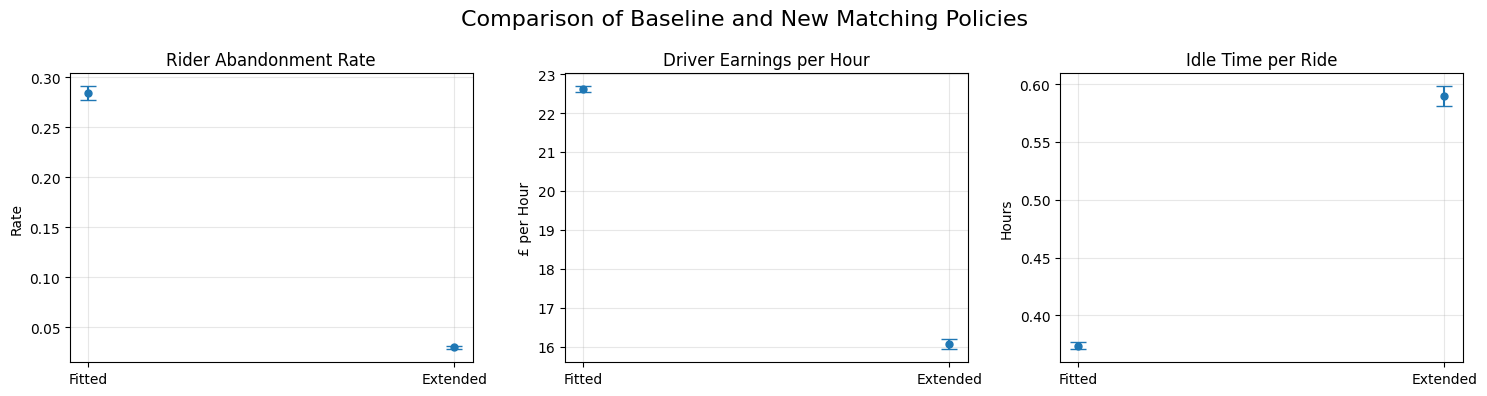

In [18]:
# function to extract mean and CI
def extract(metric):
    base = summary_bm[metric]
    imp = summary_fitted[metric]

    means = [base["mean"], imp["mean"]]
    lower = [base["mean"] - base["CI_lower"], imp["mean"] - imp["CI_lower"]]
    upper = [base["CI_upper"] - base["mean"], imp["CI_upper"] - imp["mean"]]

    return means, [lower, upper]


fig, axes = plt.subplots(1,3, figsize=(15,4))

labels = ["Fitted","Extended"]

# Rider Experience 
means, err = extract("abandonment_rate")

axes[0].errorbar(labels, means, yerr=err, fmt="o", markersize=5, capsize=6)
axes[0].set_title("Rider Abandonment Rate")
axes[0].set_ylabel("Rate")
axes[0].grid(alpha=0.3)

# Platform Performance
means, err = extract("avg_earnings_per_hour")

axes[1].errorbar(labels, means, yerr=err, fmt="o", markersize=5, capsize=6)
axes[1].set_title("Driver Earnings per Hour")
axes[1].set_ylabel("£ per Hour")
axes[1].grid(alpha=0.3)

# Driver Fairness
means, err = extract("avg_idle_time_per_ride")

axes[2].errorbar(labels, means, yerr=err, fmt="o", markersize=5, capsize=6)
axes[2].set_title("Idle Time per Ride")
axes[2].set_ylabel("Hours")
axes[2].grid(alpha=0.3)

plt.suptitle("Comparison of Baseline and New Matching Policies", fontsize=16)

plt.tight_layout()
plt.show()